## Practice Lab - Regularization Techniques

In machine learning, we often look at the exact same algorithm through different lenses — Analytical (algebra), Geometric (shapes), and Probabilistic (statistics) — to understand why it behaves the way it does. Here is a breakdown of how each view explains regularization, plus how they all tie back to the Regression view in our codes.

1. **The Regression View (The Code View)**

    This is the practical view we already know from using scikit-learn. It defines regularization by adding a penalty term directly to the standard Linear Regression loss function (Sum of Squared Errors, or SSE).

    * The Goal: Minimize the total loss.

    * The Formula:
            Total Loss = SSE + Penalty

    * What it means: 
        * If the penalty is L2 (Ridge), the loss function adds a penalty for the squared magnitudes of the coefficients: α∑wj2​.

        * If the penalty is L1 (Lasso), it adds a penalty for the absolute magnitudes of the coefficients: α∑∣wj​∣.

    This view tells us what we are optimizing, but it doesn't explain why the coefficients shrink. To understand that, we look at the other views.

<BR>

2. **The Geometric View (The Constraint View)**

    The geometric view translates the math into shapes on a graph. Instead of thinking about a penalty added to the loss, think of it as a budget constraint.

    Imagine you are trying to find the optimal coefficients (w1​,w2​) for two features.

    * The Loss Contours: Without regularization, the perfect solution is a single point (the OLS estimate). Surrounding this point are elliptical rings of increasing error. We want to find the lowest error ring.

    * The Constraint Region: Regularization draws a boundary around the origin (0,0) that the coefficients are not allowed to leave.

        * Ridge (L2 Constraint): The boundary is a perfect circle (w12​+w22​≤t).

        * Lasso (L1 Constraint): The boundary is a diamond with sharp corners (∣w1​∣+∣w2​∣≤t).

    **Why Lasso zeroes out features (The "Sharp Corners"):**

    When the elliptical rings of your error expand outward, they will eventually touch the constraint boundary.

    * Because the Lasso constraint is a diamond, the error rings are highly likely to hit the boundary at one of the sharp corners on the axes. At any corner, one of the coefficients is exactly zero.

    * Because the Ridge constraint is a circle, the error rings usually hit the smooth edge. The coefficients shrink closely toward zero together, but they rarely hit zero exactly.

<BR>

3. **The Analytical View (The Optimization View)**

    The analytical view uses calculus to explain how regularization affects the model's weights. It looks at the derivatives of the loss function to see how the optimization step behaves.

    * **In Ridge (L2)**: The derivative of the penalty αw2 is 2αw.

        * The penalty applied to a coefficient is directly proportional to its current size.

        * Big weights get pushed down very hard, while tiny weights get pushed down very gently. This is why Ridge shrinks weights but never quite forces them to zero.

    * **In Lasso (L1)**: The derivative of the penalty α∣w∣ is a constant (either +α or −α).

        * The penalty applies the exact same force to a weight whether it is 1,000 or 0.01.

        * Because the shrinking force doesn't fade as the weight gets smaller, Lasso can drive a coefficient all the way down to exactly zero and keep it there.

<BR>

4. **The Probabilistic View (The Bayesian View)**

    The probabilistic view steps away from optimization and looks at regularization through the lens of **Bayesian Statistics**.

    In normal linear regression, we assume we know nothing about the coefficients before looking at the data. In Bayesian regression, we add a prior belief about what the weights should look like before we even train the model.

    * **Ridge Regression = Gaussian (Normal) Prior:**

        * We assume before looking at the data that the coefficients follow a normal distribution centered at zero.

        * We believe that all features have some impact, but their weights are likely to be small.

    * **Lasso Regression = Laplace (Double Exponential) Prior**:

        * We assume the coefficients follow a distribution with a sharp peak at zero and very fat tails.

        * We believe that most features have an impact of exactly zero, and only a very small handful of features are truly important.








<BR>

___

<BR>

The purpose of Regularization techniques is to reduce the degree of overfitting that can occur in Regression models. Overfitting leads to poor ability of the model to make predictions on the new, unseen data. As we saw in the previous Regression Lessons, with a creation of extra features, such as through polynomial regression, a model can become easily overfit. To reduce the overfitting, we can regularize the model, or in other words, we can decrease its degrees of freedom. A simple way to regularize polynomial model is to reduce the number of polynomial degrees. For a linear regression model, regularization is typically achieved by constraining the weights of the model. Regularizer imposes a penalty on the size of the coefficients of the model.

In this lab, we will cover three types of **Regression Model that uses Regularization**:

*   Ridge regression
*   Lasso regression
*   Elastic Net

Each one has its own advantages and disadvantages. Lasso will eliminate many features and reduce overfitting in your linear model. Ridge will reduce the impact of the features that are not important in predicting your target. Elastic Net combines feature elimination from Lasso and feature coefficient reduction from the Ridge model to improve your model’s predictions.

The common features of all these regularizers include using cross-validation to select hyperparameters and applying data normalization to improve the performance.

## Objectives

After completing this lab you will be able to:

*   Understand the advantages and disadvantages of Ridge, Lasso and Elastic Net Regressions
*   Apply Ridge, Lasso and Elastic Net Regressions
*   Perform  hyperparameters Grid Search on a model using validation data


***


## **Setup**


For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01) for mathematical operations.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01) for visualizing the data.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`scipy`](https://docs.scipy.org/doc/scipy/tutorial/stats.html/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01) for statistical computations.


In [1]:
# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [2]:
import pandas as pd
import numpy as np 

import seaborn as sns 
import matplotlib.pylab as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures, scale, StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA



First, let's define some functions that will help us in our analysis.

The following function will calculate the $R^{2}$ on each feature given the input of the model.


In [3]:
def get_R2_features(model, test=True): 
    # X, X_train, y_train, X_test, y_test are global variables
    features=list(X)
    features.remove("three")
    
    R_2_train=[]
    R_2_test=[]

    for feature in features:
        model.fit(X_train[[feature]], y_train)
        
        R_2_test.append(model.score(X_test[[feature]], y_test))
        R_2_train.append(model.score(X_train[[feature]], y_train))
        
    plt.bar(features, R_2_train, label="Train")
    plt.bar(features, R_2_test,  label="Test")
    plt.xticks(rotation=90)
    plt.ylabel("$R^2$")
    plt.legend()
    plt.show()

    print(f"Training R^2 mean value {str(np.mean(R_2_train))} Testing R^2 mean value {str(np.mean(R_2_test))}")
    print(f"Training R^2 max  value {str(np.max(R_2_train))}  Testing R^2 max  value {str(np.max(R_2_test))}")


The following function will plot the estimated coefficients for each feature and find $R^{2}$ on training and testing sets.

In [4]:
def plot_coef(X, model, name=None):
    plt.bar(X.columns[2:], abs(model.coef_[2:]))
    plt.xticks(rotation=90)
    plt.ylabel("$coefficients$")
    plt.title(name)
    plt.show()

    print(f"R^2 on training data for {name} model: {model.score(X_train, y_train)}")
    print(f"R^2 on testing  data for {name} model: {model.score(X_test, y_test)}")
    

The following function plots the distribution of two inputs.

In [5]:
def plot_dis(y, yhat):
    plt.figure()
    ax1 = sns.kdeplot(y, color="r", label="Actual Value")
    sns.kdeplot(yhat, color="b", label="Fitted Values", ax=ax1)
    plt.legend()

    plt.title('Actual vs Fitted Values')
    plt.xlabel('Price (in dollars)')
    plt.ylabel('Proportion of Cars')

    plt.show()
    plt.close()

## **Reading and understanding our data**


For this lab, we will be using the car sales dataset, hosted on IBM Cloud object storage. The dataset contains all the information about cars, the name of the manufacturer, the year it was launched, all car technical parameters, and the sale price. This dataset has already been pre-cleaned and encoded (using one-hot and label encoders) in the Linear Regression Notebook. This means the data has taken care of any missing values, duplicates, and/or any formatting inconsistencies (e.g. date formats, typos in category data, etc). Also, the original categorical data has been converted into numbers. This does not mean it has been scaled, nor are they normally-transformed.


Let's read the data into *pandas* data frame and look at the first 5 rows using the `head()` method.


In [6]:
# data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML240EN-SkillsNetwork/labs/encoded_car_data.csv'

data = pd.read_csv('data/encoded_car_data.csv')
data.head()

,diesel,gas,std,turbo,convertible,hardtop,hatchback,sedan,wagon,4wd,...,wheelbase,curbweight,enginesize,boreratio,horsepower,carlength,carwidth,citympg,highwaympg,price
0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,88.6,2548.0,130.0,3.47,111.0,168.8,64.1,21.0,27.0,13495.0
1,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,88.6,2548.0,130.0,3.47,111.0,168.8,64.1,21.0,27.0,16500.0
2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,94.5,2823.0,152.0,2.68,154.0,171.2,65.5,19.0,26.0,16500.0
3,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,99.8,2337.0,109.0,3.19,102.0,176.6,66.2,24.0,30.0,13950.0
4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,99.4,2824.0,136.0,3.19,115.0,176.6,66.4,18.0,22.0,17450.0


We can find more information about the features and types using the `info()`  method.


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 36 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   diesel       205 non-null    float64
 1   gas          205 non-null    float64
 2   std          205 non-null    float64
 3   turbo        205 non-null    float64
 4   convertible  205 non-null    float64
 5   hardtop      205 non-null    float64
 6   hatchback    205 non-null    float64
 7   sedan        205 non-null    float64
 8   wagon        205 non-null    float64
 9   4wd          205 non-null    float64
 10  fwd          205 non-null    float64
 11  rwd          205 non-null    float64
 12  dohc         205 non-null    float64
 13  dohcv        205 non-null    float64
 14  l            205 non-null    float64
 15  ohc          205 non-null    float64
 16  ohcf         205 non-null    float64
 17  ohcv         205 non-null    float64
 18  rotor        205 non-null    float64
 19  eight        205 no

## Data Preparation

Let's first split our data into `X` features and `y` target.


In [8]:
X = data.drop('price', axis=1)
y = data.price

Now that we will split our data into training and testing sets, the training data is used for our model to recognize patterns using some criteria, the test data set is used for evaluating the model, as shown in the following image:


<center>
    <img src="trin-test.png">
</center>
<center>source scikit-learn.org</center>


Now, we split our data, using <code>train_test_split</code> function, into the training and testing sets, allocating 30% of the data for testing.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("number of test samples    :", X_test.shape[0])
print("number of training samples:", X_train.shape[0])


number of test samples    : 62
number of training samples: 143


## Linear Regression

In linear  regression we are trying to find the value of $\textbf{w}$ that  minimizes the Mean Squared Error (MSE), we can represent this using the following expression:


$\hat{\textbf{w}}= \underset{\textbf{w}}{\mathrm{argmin}} {
||\textbf{y}  - \textbf{Xw} ||^2_2}$


Where $\textbf{y}$ is the target, $\textbf{X}$ is the training set and $\textbf{w}$ is the parameter weights. The resulting $\hat{\textbf{w}}$ is the best value to minimize the MSE, i.e., the distance between the target $\textbf{y}$ and the estimate $\textbf{Xw}$. We do this by fitting the model.


Let's create a <code>LinearRegression</code> object, called `lm`.


In [10]:
lm = LinearRegression()

Now, let's fit the model with multiple features on our X_train and y_train data.


In [11]:
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


We apply `predict(`) function on the testing data set.


In [12]:
predicted = lm.predict(X_test)

Let's calculate the $R^2$ on both, training and testing data sets.


In [13]:
print("R^2 on training data: ",lm.score(X_train, y_train))
print("R^2 on testing  data: ",lm.score(X_test, y_test))

R^2 on training data:  0.9262722224294516
R^2 on testing  data:  0.8471124710243334


We can plot a distribution of the predicted values vs the actual values.


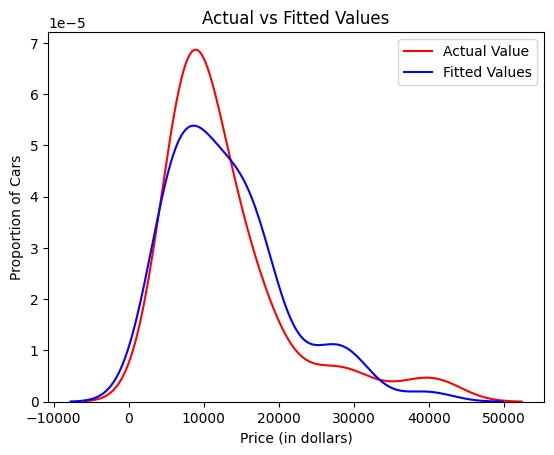

In [14]:
plot_dis(y_test, predicted)

We can view the estimated coefficients for the linear regression.


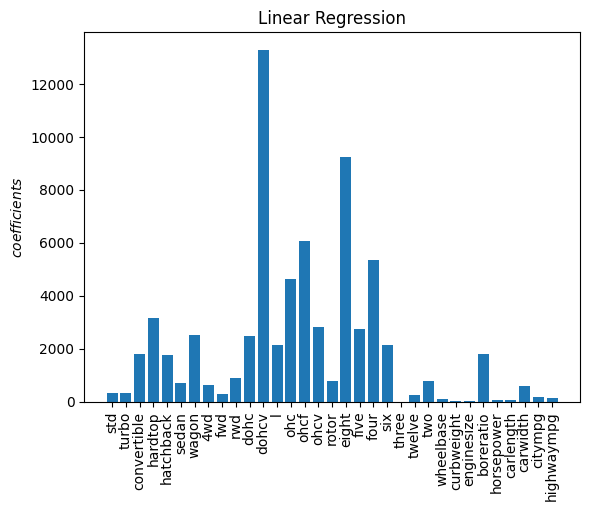

R^2 on training data for Linear Regression model: 0.9262722224294516
R^2 on testing  data for Linear Regression model: 0.8471124710243334


In [15]:
plot_coef(X, lm, name="Linear Regression")

Here is the complete list of coefficients sorted by its magnitude in ascending order.

In [16]:
pd.DataFrame(zip(X.columns, lm.coef_)).sort_values(by=1)

,0,1
13,dohcv,-1.328646e+04
21,four,-5.338370e+03
17,ohcv,-2.819953e+03
20,five,-2.742729e+03
8,wagon,-2.493649e+03
22,six,-2.146200e+03
29,boreratio,-1.781280e+03
6,hatchback,-1.770766e+03
1,gas,-7.712244e+02
7,sedan,-6.876843e+02


<BR>

## Ridge Regression


Let's review the Ridge Regression. Ridge Regression makes the prior assumption that our coefficients are normally distributed around zero. A regularization term, alpha, is added to the cost function. This forces the learning algorithm to not only fit the data but also keep the model weights as small as possible. The variance of the distribution is inversely proportional to the parameter alpha. This is also called the  L2 regularizer , as it adds a L2 penalty to the minimization term, as shown here:

$\hat{\textbf{w}}= \underset{\textbf{w}}{\mathrm{argmin}} {
||\textbf{y}  - \textbf{Xw} ||^2_2+ \alpha  ||\textbf{w}||_2 }$

We minimize the MSE, but we also penalize large weights by including their magnitude $||\textbf{w}||\_2$ in the minimization term. This additional minimization term makes the model less susceptible to noise and makes the weights smaller. Alpha controls the takeoff between MSE and penalization or regularization term and is chosen via cross-validation.


Let's see  how the parameter alpha changes the model. Note, here our test data will be used as validation data. Also, the regularization term should only be added to the cost function during the training.

Let's create a Ridge Regression object, setting the regularization parameter (alpha) to 0.01.


In [17]:
rr = Ridge(alpha=0.01)
rr

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


Like regular regression, we can fit the model using the `fit()` method.


In [18]:
rr.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


Similarly, you can obtain a prediction:


In [19]:
rr.predict(X_test)

array([27598.326873  , 21371.22387854, 10760.95940989, 12111.7976642 ,
       26104.61526939,  5420.80558182,  8038.73622302,  7558.7584293 ,
       10088.50457197,  9434.40202964, 17328.20366356,  7276.77101381,
       16442.40304417, 10820.55785225, 39642.68328022,  5532.64570913,
        2223.48274137, 15704.2551402 , 10795.80882429, 11445.69022623,
       10869.49226403, 15847.09411047, 10601.08457888,  3598.67058534,
        7007.60644617, 28598.41184812, 18455.46252113, 15173.62941095,
        4452.47193894, 16400.79617624, 26787.78275612,  5805.73648313,
        4904.13554999, 16743.20407026,  8386.05980122, 30491.9258854 ,
       12381.70808121, 12997.76584967,  6284.21248199, 16133.48808554,
        8154.05990242, 15088.646679  , 14726.67293205,  5249.70079409,
        6261.47439111,  9115.33978834,  5805.73648313,  7240.34422195,
       16679.32730582, 15561.37722608,  5019.75853115, 21822.09787812,
        7068.35655245, 11454.04169241,  4389.88795114, 16500.07849587,
      

We can calculate the $R^2$ on the training and testing data.


In [20]:
print("R^2 on training data for Ridge(0.01) model: ",rr.score(X_train, y_train))
print("R^2 on testing  data for Ridge(0.01) model: ",rr.score(X_test, y_test))

R^2 on training data for Ridge(0.01) model:  0.9262583145923291
R^2 on testing  data for Ridge(0.01) model:  0.8454081419624829


Now let's compare the Ridge Regression and the Linear Regression  models. The results on the $R^2$ are about the same, and the coefficients seem to be smaller.


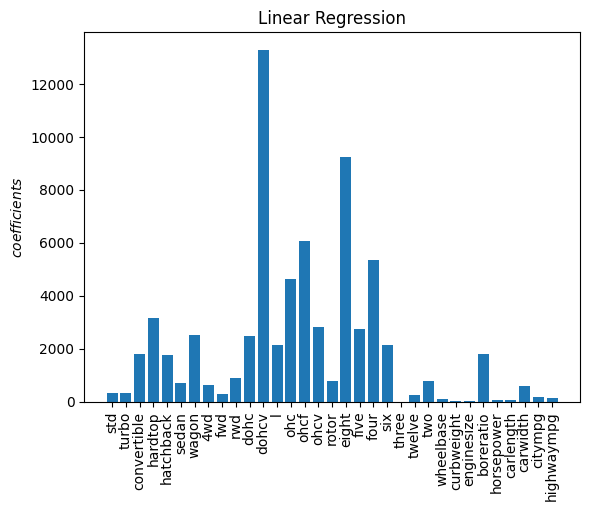

R^2 on training data for Linear Regression model: 0.9262722224294516
R^2 on testing  data for Linear Regression model: 0.8471124710243334





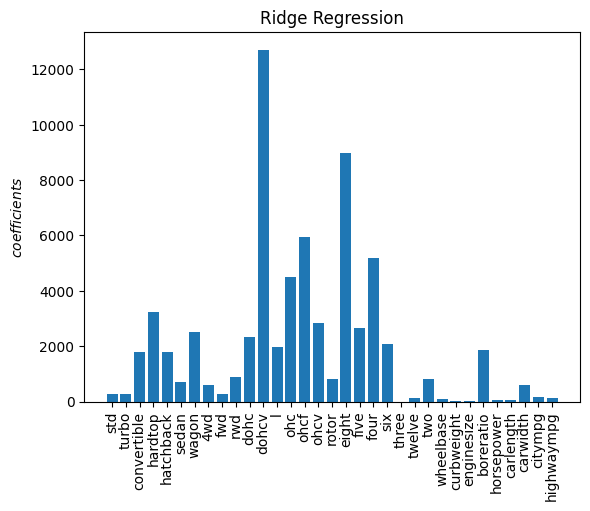

R^2 on training data for Ridge Regression model: 0.9262583145923291
R^2 on testing  data for Ridge Regression model: 0.8454081419624829


In [21]:
plot_coef(X, lm, name="Linear Regression")
print("\n\n")
plot_coef(X, rr, name="Ridge Regression")

If we increase alpha, the coefficients get smaller, but the results are not as good as our previous value of alpha.


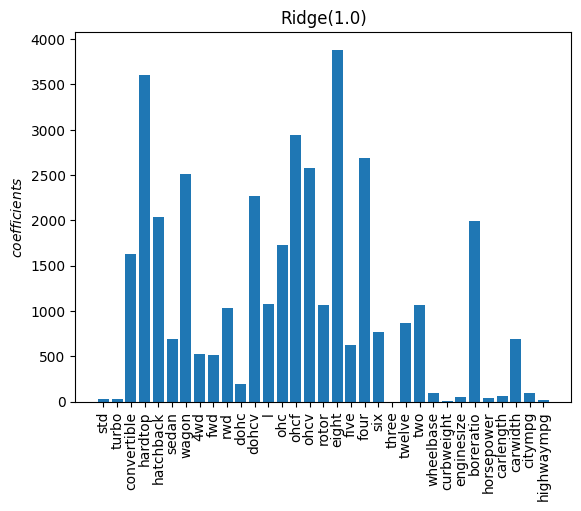

R^2 on training data for Ridge(1.0) model: 0.9190312321691605
R^2 on testing  data for Ridge(1.0) model: 0.807983068907448


In [22]:
rr = Ridge(alpha=1)
rr.fit(X_train, y_train)
plot_coef(X, rr, "Ridge(1.0)")

In general, we see that **if we increase alpha, the coefficients get smaller, but the model performance relationship gets more complex. As a result, we use the validation data to select a value for alpha.** Here, we plot the coefficients and $R^2$ of the test data on the vertical axes and alpha on the horizontal axis, as well the $R^2$ using the test data.


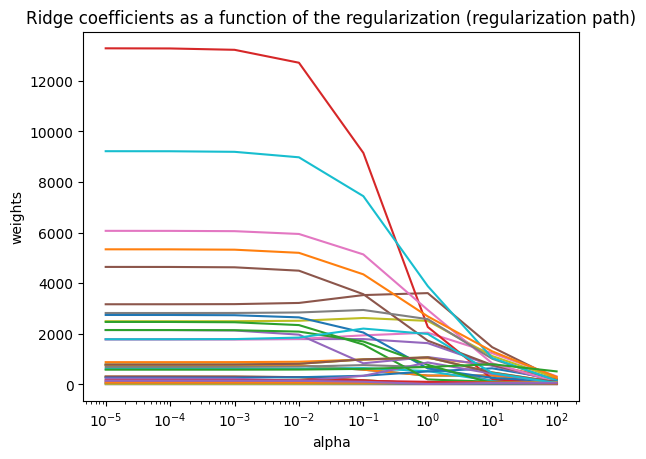

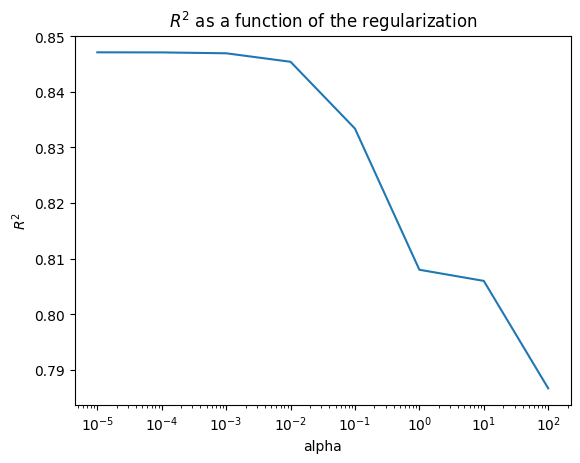

In [23]:
alphas = [0.00001,0.0001,0.001,0.01,0.1,1,10,100]
R_2=[]
coefs = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    coefs.append(abs(ridge.coef_))
    R_2.append(ridge.score(X_test,y_test))


ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale("log")
plt.xlabel("alpha")
plt.ylabel("weights")
plt.title("Ridge coefficients as a function of the regularization (regularization path)")
plt.show()


ax = plt.gca()
ax.plot(alphas, R_2)
ax.set_xscale("log")
plt.xlabel("alpha")
plt.ylabel("$R^2$")
plt.title("$R^2$ as a function of the regularization")
plt.show()          

From the above graphs, it shows that as we increase alpha, the coefficients get smaller but the $R^2$ score decreases, meaning the model performs best at very small alpha values and begins to underfit as alpha exceeds 0.01.


## Exercise 1

In this Exercise, plot the MSE as a function of alpha. What pattern do you notice?


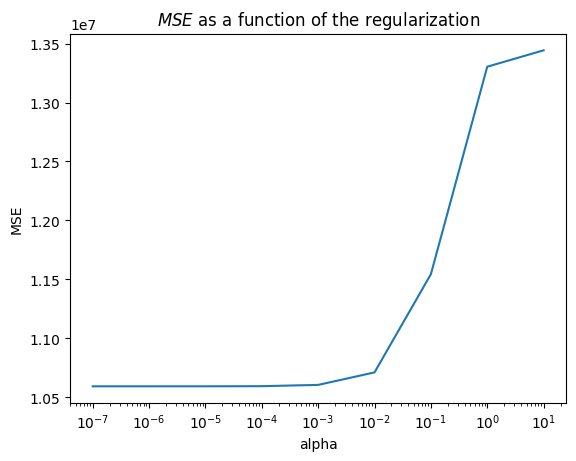

In [24]:
alphas = [0.0000001,0.00001,0.0001,0.001,0.01,0.1,1,10]
MEAN_SQE=[]

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    MEAN_SQE.append(mean_squared_error(ridge.predict(X_test),y_test))

ax = plt.gca()
ax.plot(alphas, MEAN_SQE)
ax.set_xscale("log")
plt.xlabel("alpha")
plt.ylabel("MSE")
plt.title("$MSE$ as a function of the regularization")
plt.show()

The above graph shows the MSE (Mean Square Error) on the y-axis:
* MSE is a measure of "error", Lower is better.
* As the alpha moves from 0.0001 toward 0.1, the line goes up, not down.
* This means as alpha increases, the error increases.

The "optimal point" is at the lowest value, which is at the smallest possible alpha when the MSE is about to rise. This is when alpha = 0.0001.

**Conclusion**: 

In this model, any amount of Ridge regularization increases the error. The model performs best with almost zero regularization (alpha near 0.0001), meaning the unregularized model is already sufficiently robust, and adding further penalty only hurts performance.

In addition, just observing and comparing the $R^2$ scores from the Linear and Ridge Regression models shows that they are very closed (0.8471 vs 0.8454 - a difference of less than 0.2%). **In machine learning, when a model with a penalty performs almost identically to the unconstrained model, it means the penalty is not doing any "useful" work**. In this case, the Ridge model is not helping because the baseline Linear Regression model is already stable.

<BR>

## Pipeline


We can also create a Pipeline object and apply a set of transforms sequentially. Then, we can apply Polynomial Features, perform data standardization then apply Ridge regression.  Data Pipelines simplify the steps of processing the data. We use the module `Pipeline` to create a pipeline. We also use `StandardScaler` step in our pipeline. Scaling our data is necessary step in Ridge regression as it will penalize features with a large magnitude.

Now, we create a pipeline object.


In [25]:
Input=[ ('polynomial', PolynomialFeatures(include_bias=False,degree=2)),('ss',StandardScaler() ), ('model',Ridge(alpha=1))]
pipe = Pipeline(Input)

We fit the object.


In [26]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomial', ...), ('ss', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


We can calculate the score on the test data.


In [27]:
predicted=pipe.predict(X_test)
pipe.score(X_test, y_test)

0.8789668271159832

Looking for hyperparameters can get difficult with loops. The problem will get worse as we add more transforms such as polynomial transform. Therefore, we can use `GridSearchCV` to make things simpler.


## GridSearchCV


To search for the best combination of hyperparameters we can create a  `GridSearchCV()` function as a dictionary of parameter values. The parameters of pipelines can be set by using the name of the key, separated by "\__", then the parameter. Here, we look for different polynomial degrees and different values of alpha.


In [28]:
param_grid = {
    "polynomial__degree": [1,2,3,4],
    "model__alpha":[0.0001,0.001,0.01,0.1,1,10]
}

Keys of the dictionary follow a standard label pattern starting with the "object name \__" followed by the parameter appropriate for the object. The assigned values is a list of the parameter's value to iterated. Note the "object name" must match those defined in the Pipeline object created previously. In the above example we have:

<b>polynomial\_\_degree</b>: is the degree of the polynomial; in this case 1, 2, 3, 4 and 5.

<b>model\_\_alpha </b>: Regularization strength; must be a positive float.

We then create a `GridSearchCV` object and fit it. The method trains the model and the hyperparameters are selected via exhaustive search over the specified values. The value of n_jobs parameter is use to allocate the number of precessor to use. The default is using one CPU core. To use all available cores, use a value of -1. Here we are using 2 CPU cores.

In [29]:
search = GridSearchCV(pipe, param_grid, n_jobs=2)

search.fit(X_train, y_train)
search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ge(alpha=1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.0001, 0.001, ...], 'polynomial__degree': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also

The `search.cv_results_` returns a python dict containing all the metrics, times, and evaluation scores from every single combination of hyperparameters tested. We can input the results into *pandas* `DataFrame()` as a dictionary with keys as column headers and values as columns and display the results.

In [30]:
pd.DataFrame(search.cv_results_).head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,param_polynomial__degree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004333,0.000720,0.001400,0.000289,0.0001,1,"{'model__alpha': 0.0001, 'polynomial__degree': 1}",0.732398,0.667762,0.942160,0.871065,0.682438,0.779165,0.108597,9
1,0.005253,0.000243,0.001657,0.000163,0.0001,2,"{'model__alpha': 0.0001, 'polynomial__degree': 2}",-0.965176,-0.003728,-0.094067,-4.630618,-1.002718,-1.339261,1.698257,22
2,0.017745,0.002372,0.002549,0.000236,0.0001,3,"{'model__alpha': 0.0001, 'polynomial__degree': 3}",-0.846010,-3.023706,-2.861025,-1.443010,-1.464688,-1.927688,0.859265,23
3,0.149569,0.015662,0.014929,0.002160,0.0001,4,"{'model__alpha': 0.0001, 'polynomial__degree': 4}",-2.180161,-4.494954,-4.848157,-1.889425,-3.595880,-3.401716,1.191997,24
4,0.005423,0.001077,0.001596,0.000108,0.0010,1,"{'model__alpha': 0.001, 'polynomial__degree': 1}",0.732422,0.667772,0.942164,0.871078,0.682524,0.779192,0.108581,8


The columns in this dataframe can be grouped into three main categories:
1. The Parameters (What was tested)

* These columns tell us the exact hyperparameter values that were used for each specific run.

    * params: A list of dictionaries showing the complete hyperparameter settings for that combination.

    * param_X: Individual columns for each hyperparameter (e.g., param_alpha if we are testing Ridge or Lasso).

2. Time Metrics (How long it took)

* These columns measure the performance speed, which is incredibly useful when managing large datasets.

    * mean_fit_time: The average time it took to train the model on the training folds.

    * std_fit_time: The standard deviation of the training time.

    * mean_score_time: The average time it took to make predictions on the validation folds.

3. Test & Train Scores (The Performance)

* This is where the actual evaluation metrics live. If our GridSearchCV uses 5-fold cross-validation, the model creates 5 different splits.

    * split0_test_score, split1_test_score, ... split4_test_score: The score of the model on each specific validation fold.

    * mean_test_score: The average performance across all folds. This is the main score used to rank the models.

    * std_test_score: The variance of the score across the folds. (A high standard deviation means our model's performance is unstable).

    * rank_test_score: An integer ranking of the combinations. The combination with a rank of 1 is the best model, and its parameters will match search.best_params_.

<BR>

Instead of printing the whole dictionary, we can, for example, extract just the key information to inspect our trial runs:

```python
# Sort by the best performing model first
sorted_results = search.sort_values(by="rank_test_score")

# Display only the hyperparameters and the performance
print(sorted_results[["params", "mean_test_score", "std_test_score", "rank_test_score"]])

```


Beside `cv_results_` there are some other useful attributes available from GridSearchCV, e.g. :

`best_score_`: mean cross-validated score of the `best_estimator`.

`best_params_dict`: parameter setting that gives the best results on the hold-out data.

In [31]:
print("best_score_: ",search.best_score_)
print("best_params_: ",search.best_params_)

best_score_:  0.8720367357066007
best_params_:  {'model__alpha': 10, 'polynomial__degree': 2}


Once we call `search.fit(X_train, y_train)`, the `GridSearchCV` object doesn't just hold the results of our trials — it actually transforms itself into the best performing model from the grid.

We can use it directly to make predictions on our test data:


In [32]:

predict = search.predict(X_test)

predict 

array([30903.03765092, 23959.40886577,  9479.23784499, 13565.35356241,
       28579.65716496,  6304.25672926,  6583.34397234,  8045.9676453 ,
        8609.49490676,  9258.30927411, 14161.92398937,  7064.656928  ,
       17369.17195974, 10622.50446159, 40442.34852823,  6435.25658865,
       -1671.0246256 , 13555.86035342,  9933.24405079,  9358.46879068,
       10379.83122929, 14845.47794683,  3652.64571964,  3189.13904682,
        7155.53959618, 32300.3759433 , 10726.99924888, 16540.06247528,
        5577.15710177, 17304.09531097, 28667.21031119,  6554.235394  ,
        5547.7872642 , 21836.54871944,  7693.04693925, 27252.89916535,
       13978.46840018, 13539.55291633,  6272.57325554, 13999.91030984,
        6816.48699277, 13115.60478653, 14532.40969315,  6568.72392904,
        6613.35511383,  9128.61080739,  6554.235394  ,  6335.52712991,
       15645.84472447, 13459.30924852,  5345.7044892 , 15701.34738144,
        6241.40892908, 10141.17008462,  5527.17931522, 13078.28077423,
      

Alternatively, we can find the best model, and use it to do the same prediction.

In [33]:
best = search.best_estimator_
best

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomial', ...), ('ss', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


As we can see from the above output, it is second degree polynomial with alpha value of 10.
Now, let's make a prediction.


In [34]:
predict = best.predict(X_test)
predict

array([30903.03765092, 23959.40886577,  9479.23784499, 13565.35356241,
       28579.65716496,  6304.25672926,  6583.34397234,  8045.9676453 ,
        8609.49490676,  9258.30927411, 14161.92398937,  7064.656928  ,
       17369.17195974, 10622.50446159, 40442.34852823,  6435.25658865,
       -1671.0246256 , 13555.86035342,  9933.24405079,  9358.46879068,
       10379.83122929, 14845.47794683,  3652.64571964,  3189.13904682,
        7155.53959618, 32300.3759433 , 10726.99924888, 16540.06247528,
        5577.15710177, 17304.09531097, 28667.21031119,  6554.235394  ,
        5547.7872642 , 21836.54871944,  7693.04693925, 27252.89916535,
       13978.46840018, 13539.55291633,  6272.57325554, 13999.91030984,
        6816.48699277, 13115.60478653, 14532.40969315,  6568.72392904,
        6613.35511383,  9128.61080739,  6554.235394  ,  6335.52712991,
       15645.84472447, 13459.30924852,  5345.7044892 , 15701.34738144,
        6241.40892908, 10141.17008462,  5527.17931522, 13078.28077423,
      

We can calculate the $R^2$ on the test data.


In [35]:
best.score(X_test, y_test)

0.9052548681611051

As we see, using Ridge Regression polynomial function works better than all other models. Finally, we can train our model on the entire data set!

In [36]:
best.fit(X,y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomial', ...), ('ss', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## Exercise 2

Perform grid search on the following features and plot the results by completing the following lines of code:


In [37]:
columns=['wheelbase', 'curbweight', 'enginesize', 'boreratio', 'horsepower', 'carlength', 'carwidth', 'citympg']

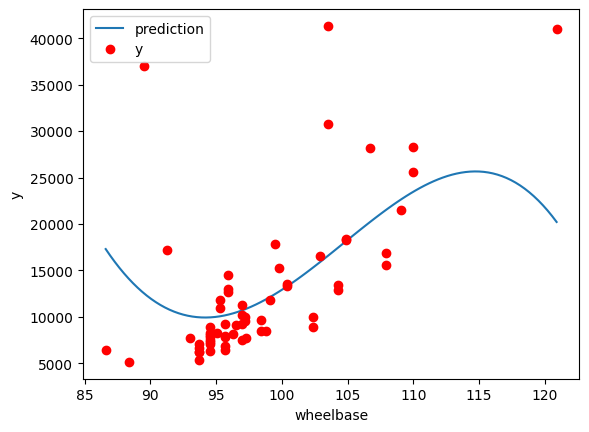

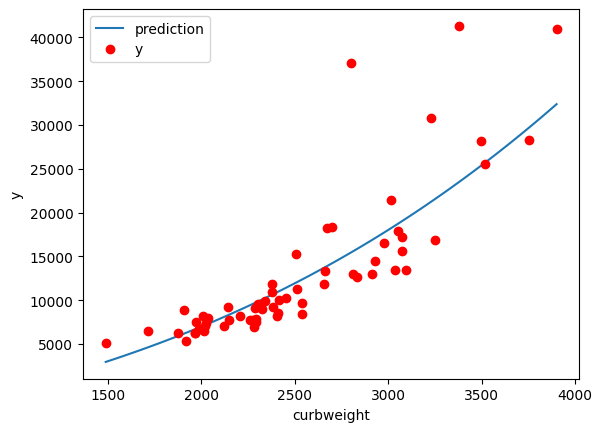

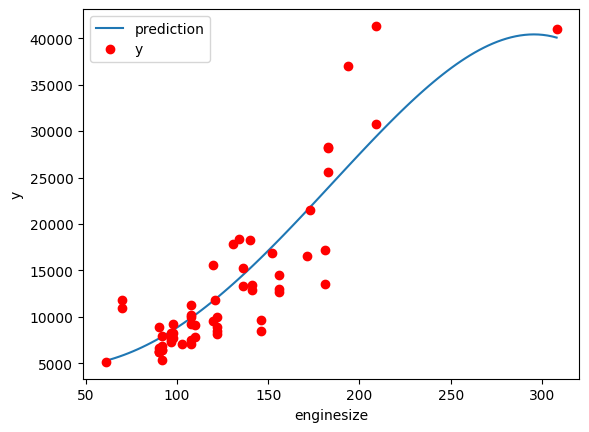

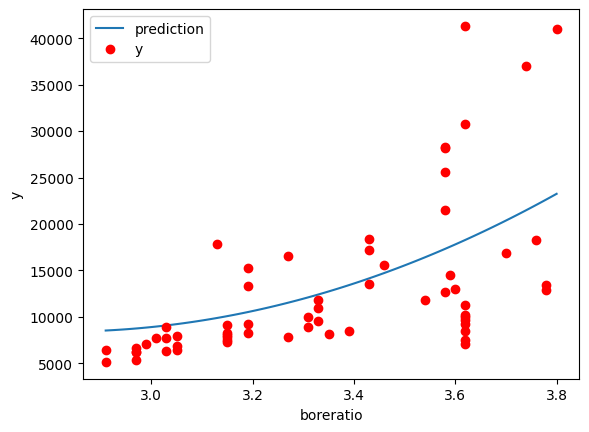

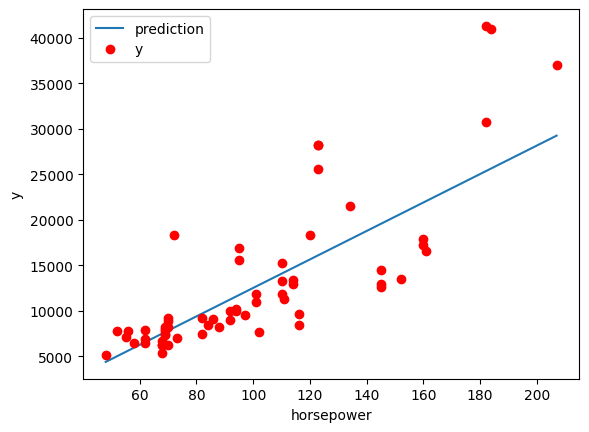

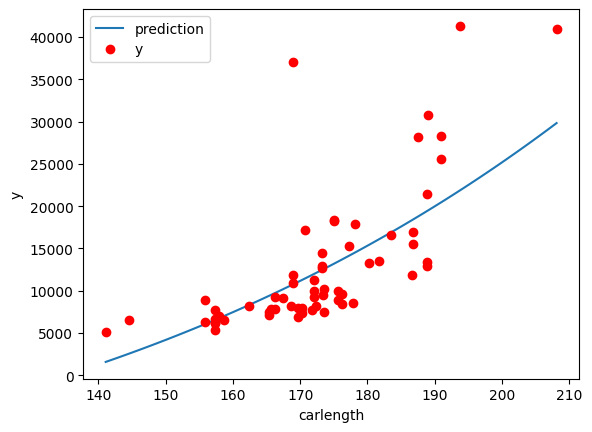

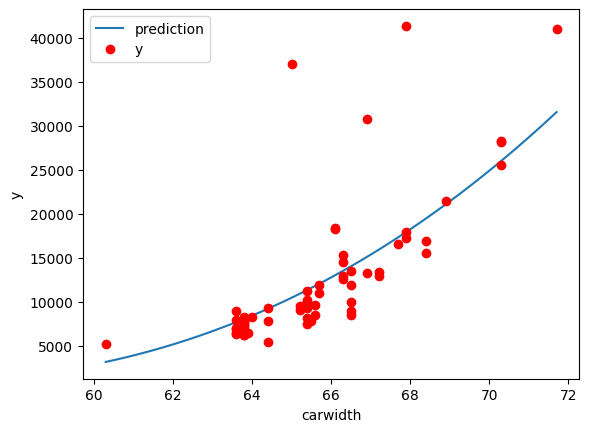

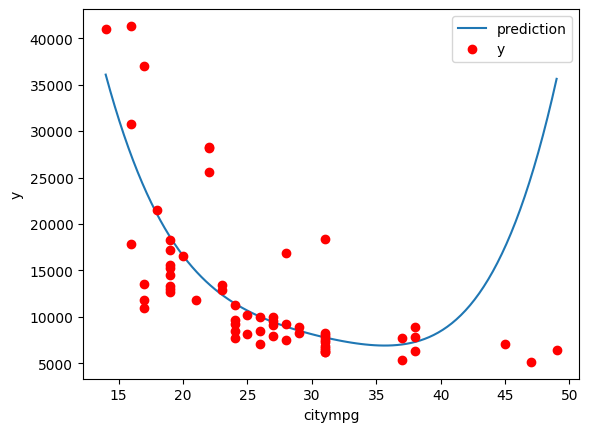

In [38]:
for column in columns:
    search.fit(X_train[[column]], y_train)
    x=np.linspace(X_test[[column]].min(), X_test[[column]].max(),num=100)
    plt.plot(x,search.predict(x.reshape(-1,1)),label="prediction")
    plt.plot(X_test[column],y_test,'ro',label="y")
    plt.xlabel(column)
    plt.ylabel("y")
    plt.legend()
    plt.show()


## Lasso Regression


In this section, let's review the Lasso (Least Absolute Shrinkage and Selection Operator) Regression. Lasso Regression makes the prior assumption that our coefficients have Laplace (double-exponential) distribution around zero. The scale parameter of the distribution is inversely proportional to the parameter alpha. The main advantage of LASSO Regression is that many coefficients are set to zero, therefore they are not required. This has many advantages, one of them is that you may not need to collect and/or store all of the features. This may save resources. For example, if the feature was some medical test, you would no longer need to perform that test. Let's see how the parameter alpha changes the model.  We minimize the MSE, but we also penalize large weights by including their sum of absolute values $||\textbf{w}||_1$ , symbolically:


$\hat{\textbf{w}}= \underset{\textbf{w}}{\mathrm{argmin}} {
||\textbf{y}  - \textbf{Xw} ||^2_2+ \alpha  ||\textbf{w}||_1 }$

This regularization or penalty term makes many coefficients zero, making the model easy to understand and can also be used for feature selection. There are some drawbacks to this technique. It takes longer time to train and the solution may not be unique. Alpha controls the trade-off between MSE and penalization or regularization term and is chosen via cross-validation.  Let's see how the parameter alpha changes the model. Note, as before, our test data will be used as validation data. Let's create a Lasso Regression object, setting the regularization parameter (alpha) to 0.01.


In [39]:
la = Lasso(alpha=0.01)
la.fit(X_train,y_train)
la

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.01
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


Let's make a prediction.


In [40]:
predicted = la.predict(X_test)
predicted

array([27653.22353453, 21440.83485051, 10768.17892472, 12147.86491396,
       26101.4231047 ,  5426.63186688,  8109.12572402,  7548.43583027,
       10106.99306711,  9477.10351207, 17334.36955214,  7255.11222781,
       16451.81989256, 10813.30231853, 39694.78786279,  5539.81756182,
        -466.02852127, 15704.60106258, 10787.18667859, 11454.08100741,
       10845.27202677, 15783.81531736, 10531.97700623,  3625.17908373,
        7008.92512446, 28652.43219019, 18375.53759481, 15177.29250235,
        4451.3795471 , 16390.36525481, 26765.45499789,  5818.61353594,
        4887.80913673, 16632.26078711,  8385.78653734, 30408.60069614,
       12370.64380191, 12980.12237324,  6297.32853601, 16138.6347955 ,
        8143.33012298, 15098.97617906, 14726.32950669,  5250.82055769,
        6252.44142986,  9120.37856872,  5818.61353594,  7232.67630672,
       16689.6474234 , 15562.04464584,  5043.85295482, 21858.2779812 ,
        7104.52566669, 11435.57822728,  4388.21555444, 16509.90280152,
      

Let's calculate the $R^2$ on the training and testing data and see how it performs compared to the other methods.


In [41]:
print("R^2 on training data for Lasso(0.01) model: ",la.score(X_train, y_train))
print("R^2 on testing  data for Lasso(0.01) model: ",la.score(X_test, y_test))

R^2 on training data for Lasso(0.01) model:  0.9262722171108666
R^2 on testing  data for Lasso(0.01) model:  0.8414433846160775


Let's compare the Lasso Regression to the  Ridge Regression model with the results on the $R^2$ and coefficients :

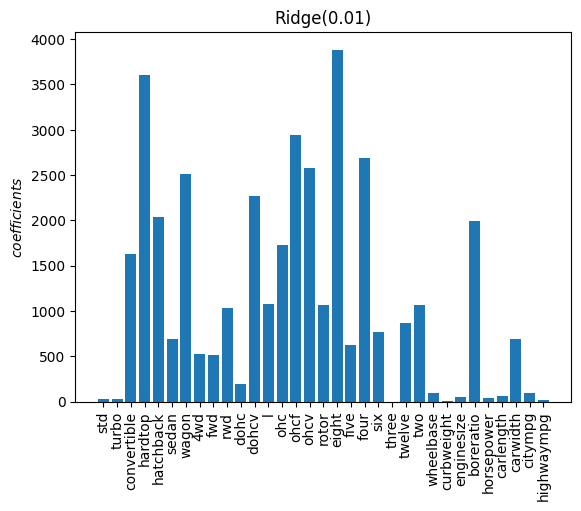

R^2 on training data for Ridge(0.01) model: 0.9190312321691605
R^2 on testing  data for Ridge(0.01) model: 0.807983068907448





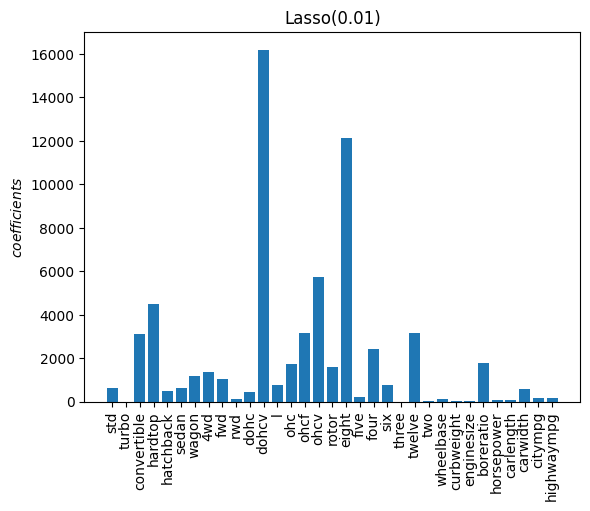

R^2 on training data for Lasso(0.01) model: 0.9262722171108666
R^2 on testing  data for Lasso(0.01) model: 0.8414433846160775


In [42]:
plot_coef(X,rr,name="Ridge(0.01)")
print("\n\n")
plot_coef(X,la,name="Lasso(0.01)")

Looking at the above visual outputs and performance metrics, we can compare Ridge and Lasso on this dataset across three key dimensions: **Feature Selection**, **Coefficient Magnitudes**, and **Generalization (R2 Scores)**.

1. **Feature Selection** (Zero vs. Non-Zero Coefficients)

* This is the most striking difference between the two bar charts.

    * Ridge(0.01): Ridge keeps all features in the game. Looking closely at the bars for terms like turbo, enginesize, horsepower, and highwaympg, the bars are extremely small, but they are not zero. Ridge shrinks them toward zero but refuses to completely eliminate them.

    * Lasso(0.01): Lasso acts as a filter. Notice that several features—such as convertible, dohc, ohc, rotor, three, two, and curbweight—have absolutely no bars. Their coefficients have been forced exactly to zero, effectively dropping them from the model.

2. **Coefficient Magnitudes**

* Because of the different mathematical penalties, the scale of the remaining coefficients differs substantially.

    * Ridge(0.01): The highest coefficient (for eight) peaks at around 3,900. The weights are distributed more evenly across multiple features (like hardtop, ohcf, ohcv, four, and boreratio).

    * Lasso(0.01): The scale of the y-axis jumps up to 16,000. Because Lasso completely zeroed out many features, it compensated by assigning much larger weights to the remaining features it deemed highly important — specifically dohcv (exceeding 16,000) and eight (around 12,000).

3. **Generalization (R2 Scores)**

* Let's analyze the performance metrics printed below the graphs:

|Model|Training R2|Testing R2|Gap (Overfitting)|
|---|---|---|---|
|Ridge(0.01)|0.9190|0.8080|0.1110|
|Lasso(0.01)|0.9263|0.8414|0.0849|

* **Higher Overall Performance**: Lasso wins on both training and test data. An R2 of 0.8414 on the test set is significantly better than Ridge's 0.8080.

* **Better Generalization**: The gap between the training and testing scores for Ridge is about 11.1%, while Lasso narrows that gap to 8.5%. This means Lasso is doing a better job of handling overfitting on this specific dataset.

**The Verdict**

For this specific data, Lasso is the clear winner. By eliminating the redundant or irrelevant features entirely, Lasso created a simpler, more interpretable model that generalizes much better to unseen test data. Ridge kept too many unnecessary features active at small weights, which introduced noise and dragged down the test performance.

<BR>

Similar to the Ridge Regression, if we increase the value of alpha, the coefficients will get smaller. Additionally, many coefficients become zero. Moreover, the model performance relationship becomes more complex. As a result, we use the validation data to select a value for alpha. Here, we plot the coefficients and $R^2$ of the test data on the vertical axes and alpha values on the horizontal axis.


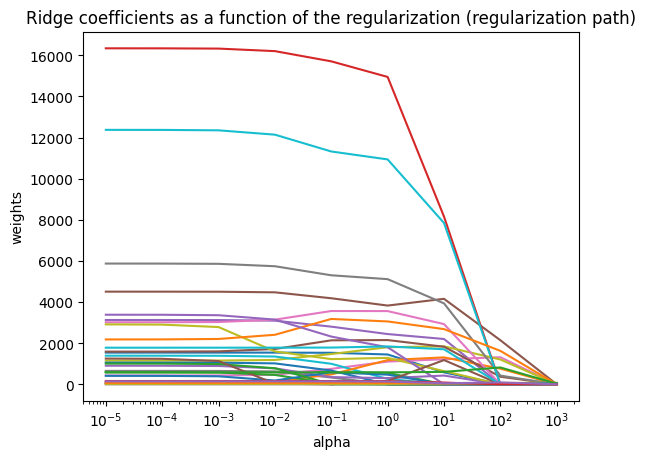

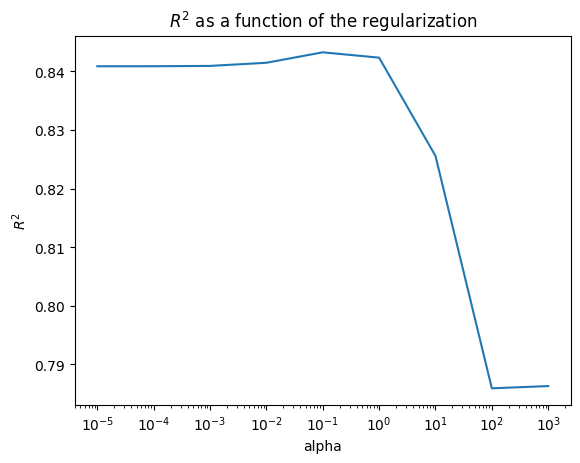

In [43]:
alphas = [0.00001,0.0001,0.001,0.01,0.1,1,10,100,1000]
R_2=[]
coefs = []
for alpha in alphas:
    la=Lasso(alpha=alpha)
    
    la.fit(X_train, y_train)
    coefs.append(abs(la.coef_))
    R_2.append(la.score(X_test,y_test))


ax = plt.gca()
ax.plot(alphas, coefs)
ax.set_xscale("log")
plt.xlabel("alpha")
plt.ylabel("weights")
plt.title("Ridge coefficients as a function of the regularization (regularization path)")
plt.show()


ax = plt.gca()
ax.plot(alphas, R_2)
ax.set_xscale("log")
plt.xlabel("alpha")
plt.ylabel("$R^2$")
plt.title("$R^2$ as a function of the regularization")
plt.show()

## Lasso - Pipeline


We can also create a Pipeline object and apply a set of transforms sequentially. Then, we can apply polynomial features, perform data standardization, then apply Lasso Regression.  We also use `StandardScaler` as a step in our pipeline. Scaling your data is necessary step in LASSO Regression, as it will penalize features with a large magnitudes.

We start by creating a pipeline object.


In [44]:
Input=[ ('polynomial', PolynomialFeatures(include_bias=False,degree=2)),('ss',StandardScaler() ), ('model',Lasso(alpha=1, tol=0.2))] # tol - is for Tolerance (controls stopping criterion)
pipe = Pipeline(Input)

Then we fit the object, and make our predictions.


In [45]:
pipe.fit(X_train, y_train)
pipe.predict(X_test)

array([27638.40615726, 25193.4225569 ,  9540.51989197, 11846.3552167 ,
       29910.27976213,  6763.7468756 ,  7641.24341483,  7685.09086631,
        8159.0888212 , 10070.5614497 , 16146.30157165,  8495.45878452,
       17221.46659223, 11173.90847907, 37793.90880269,  7075.60152085,
        4685.58897576, 12840.89650783,  9503.54540902,  7848.83795211,
       10205.7000406 , 14560.80011868,  4269.41981622,  3029.92473899,
        6657.24723604, 28244.1861882 , 10960.07731608, 16035.31718184,
        6217.03685991, 16702.51523609, 29737.3487888 ,  6631.42716864,
        7302.38894587, 23394.51085554,  8996.52485981, 35648.35063023,
       11673.02535401, 14307.76521226,  6037.19612759, 13013.53298152,
        7313.72750317, 16870.85976321, 15109.35946846,  6793.62756442,
        6633.70044783,  8925.34478795,  6631.42716864,  5689.70352573,
       16113.38552048, 12809.64838902,  5981.43728204, 17262.4751753 ,
        7739.10734231, 10868.67734225,  6191.38095749, 15690.29720238,
      

We can calculate the $R^2$ on the training and testing data sets.


In [46]:
print("R^2 on training data for Lasso(1.0): ",pipe.score(X_train, y_train))
print("R^2 on testing  data for Lasso(1.0): ",pipe.score(X_test,y_test))

R^2 on training data for Lasso(1.0):  0.9490719402078074
R^2 on testing  data for Lasso(1.0):  0.8539774972361781


As we see, some individual features perform similarly to using all the features (we removed the feature `three` ). Additionally, we see the smaller coefficients seem to correspond to a larger $R^{2}$, therefore  larger coefficients correspond to overfiting.


## Lasso - GridSearchCV

To search for the best combination of hyperparameters, we can create a  `GridSearchCV()` function as a dictionary of parameter values. The parameters of pipelines can be set by using the name of the key, separated by "\__", then the parameter. Here, we look for different polynomial degrees and different values of alpha.


In [47]:
param_grid = {
    "polynomial__degree": [ 1, 2,3,4,5],
    "model__alpha":[0.0001,0.001,0.01,0.1,1,10]
}

To search for the best combination of hyperparameters, we create a  `GridSearchCV` object with a dictionary of parameter values.


In [48]:
search = GridSearchCV(pipe, param_grid, n_jobs=1)
search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...1, tol=0.2))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.0001, 0.001, ...], 'polynomial__degree': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is al

Now, we can find the best model.


In [49]:
best = search.best_estimator_
best

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomial', ...), ('ss', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


The best estimator has a alpha = 10 with a PolynomialFeatures power = 3.

We can calculate the $R^2$ on the test data.


In [50]:
best.score(X_test,y_test)

0.8682632196298113

## Elastic Net

In this section, let's review the Elastic Net Regression. It combines L1 and L2 priors as regularizes or penalties. So, we can combine the two as follows:


$\hat{\textbf{w}}= \underset{\textbf{w}}{\mathrm{argmin}} {
||\textbf{y}  - \textbf{Xw} ||^2_2+ \alpha  \rho||\textbf{w}||\_1
0.5 \alpha (1 - \rho)  ||\textbf{w}||^2_2 } $


Additionally to the alpha term ($\alpha$), we have a mixing parameter, $\rho$ (also known as l1_ratio), such that 0 $\le$ $\rho$ $\le$ 1. For $\rho$=0, the penalty is an L2 regularization (pure Ridge). For $\rho=1$, it is L1 regularization (pure Lasso); otherwise, it is a combination of L1 and L2. In *scikit-learn* the parameter is called  `l1_ratio`. Unlike the Ridge Regression, Elastic Net finds zero coefficients. In many cases Elastic Net performs better than Lasso, as it includes features that are correlated with one another. One drawback of the Elastic Net is there are two hyperparameters.  Lets create a model where `alpha=0.1`and `l1_ratio=0.5` and fit the data with this model.


In [51]:
enet = ElasticNet(alpha=0.1, l1_ratio=0.5)
enet.fit(X_train,y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.1
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


Let's make a prediction.


In [52]:

predicted = enet.predict(X_test)
predicted

array([26714.4824089 , 19598.86415276, 11024.3029392 , 11679.04507242,
       25740.32929708,  5425.27067897,  6492.10075795,  7979.31096963,
        9441.2650813 ,  7728.1460593 , 17205.72565446,  7549.36642758,
       17093.94716773, 11067.08318609, 38030.67040642,  5173.87911905,
       -2331.87701878, 16423.45486169, 11415.21305535, 10577.74696404,
       11848.19038931, 19872.63755179,  8835.15390216,  3142.56776653,
        6802.04471906, 27470.28396862, 17637.18797759, 15852.62423984,
        5198.71568241, 16985.26243271, 26664.52966942,  5348.56519643,
        6061.83530148, 21725.20978558,  8177.27745998, 28446.31214472,
       12166.00173012, 11507.24747393,  5939.50279689, 16588.99788837,
        8436.42603568, 14494.96360956, 15355.26743358,  5051.66342515,
        6752.48760013,  8994.96117254,  5348.56519643,  7321.87784004,
       17313.7254499 , 16370.86775869,  4462.04370198, 21268.21419309,
        5963.58343566, 12081.52515186,  5174.73611014, 16553.12452435,
      

Let's calculate the $R^2$ on the test data.


In [53]:
print("R^2 on training data for ElasticNet(0.1,0.5): ", enet.score(X_train, y_train))
print("R^2 on testing  data for ElasticNet(0.1,0.5): ", enet.score(X_test,y_test))

R^2 on training data for ElasticNet(0.1,0.5):  0.8988174004967847
R^2 on testing  data for ElasticNet(0.1,0.5):  0.8072608281341807


If we compare the Elastic Net to Lasso Regression and  Ridge Regression, we see the results on the $R^2$ are better than the Elastic Net and many of the coefficients are zero.


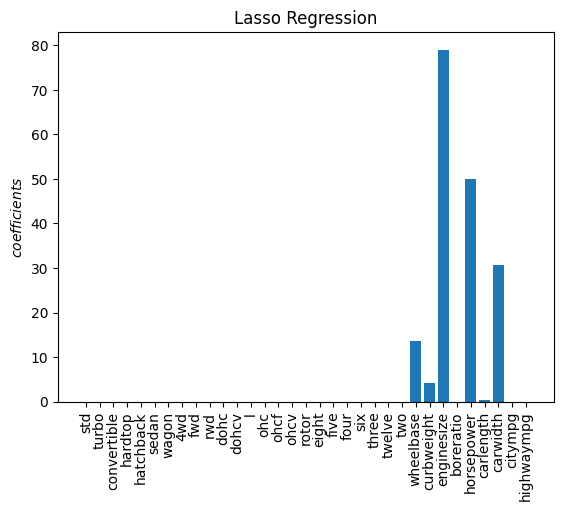

R^2 on training data for Lasso Regression model: 0.8283406619647624
R^2 on testing  data for Lasso Regression model: 0.7863171813893053





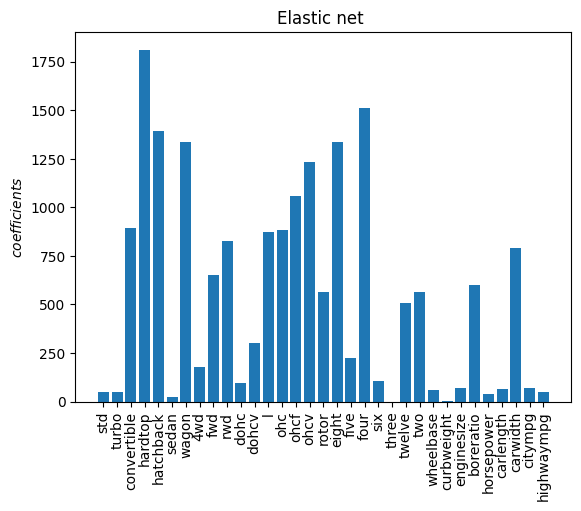

R^2 on training data for Elastic net  model: 0.8988174004967847
R^2 on testing  data for Elastic net  model: 0.8072608281341807


In [54]:
plot_coef(X,la,name="Lasso Regression")
print("\n\n")
plot_coef(X,enet,name="Elastic net ")

## graph that leads to error 

Again, looking at the above visual outputs and performance metrics, we can compare Elastic Net and Lasso on this dataset across three key dimensions: **Feature Selection**, **Coefficient Magnitudes**, and **Generalization (R2 Scores)**.

1. **Feature Selection** (Zero vs. Non-Zero Coefficients)

* The difference in how these two models handle the features is night and day.

    * Elastic Net: By introducing a blend of both L1 and L2 penalties, Elastic Net behaves much more conservatively. It retains almost all the features. Notice that while features like std, turbo, and sedan have very small bars, they are not zero. It avoids dropping variables entirely, opting instead to shrink them.

    * Lasso Regression: In this run, Lasso is behaving with extreme sparsity. Out of approximately 35 available features, Lasso has completely eliminated almost all of them. Only 5 features survive with non-zero coefficients: wheelbase, curbweight, enginesize, horsepower, and carlength. It has stripped the model down to its absolute bare essentials.

2. **Coefficient Magnitudes**

* The scale of the y-axis tells a critical story about the impact of the surviving variables.

    * Elastic Net: The y-axis scale is much larger, peaking near 1,800. Because the L2 penalty prevents coefficients from hitting zero, the model distributes its weights across many features. hardtop, four, hatchback, wagon, and eight retain massive weights.

    * Lasso Regression: The y-axis scale is very small, topping out around 80. The remaining 5 features have weights ranging from roughly 1 to 78. This indicates that the features were heavily penalized or potentially scaled beforehand, resulting in highly condensed weights.

3. **Generalization (R2 Scores)**

* Let's analyze the performance metrics printed below the graphs:

|Model|Training R2|Testing R2|Gap (Overfitting)|
|---|---|---|---|
|Elastic Net|0.8988|0.8073|0.0915|
|Lasso|0.8283|0.7863|0.0420|

* **Fit vs. Generalization**: Elastic Net captures more variance on the training data (0.8988 vs. Lasso's 0.8283). Because it keeps more features active, it is more flexible.

* **Predictive Power**: Elastic Net wins on test performance (0.8073 vs. Lasso's 0.7863). This indicates that Lasso was slightly too aggressive in its feature elimination, causing it to underfit slightly by throwing away useful signals.

* **The Stability Trade-off**: Lasso has a much smaller gap between its training and test scores (4.2%). It is a very stable, low-variance model, but it sacrificed a bit of accuracy to achieve that simplicity.

<BR>

**The Verdict**

For this specific dataset, Elastic Net is the better performing model, though it comes with a trade-off:

* **Choose Elastic Net** (R2=0.807) if your primary goal is maximizing predictive accuracy on new data. It strikes a superior balance by letting correlated features work together instead of aggressively dropping them.

* **Choose Lasso** (R2=0.786) if your goal is simplicity and extreme interpretability. A model with only 5 features is incredibly easy to explain to stakeholders, even if you give up about 2% in R2 performance.

<BR>

## Exercise 3

Create and fit the Elastic Net model and the Ridge Regression models and plot the coefficients for both models using the `plot_coef()`function.


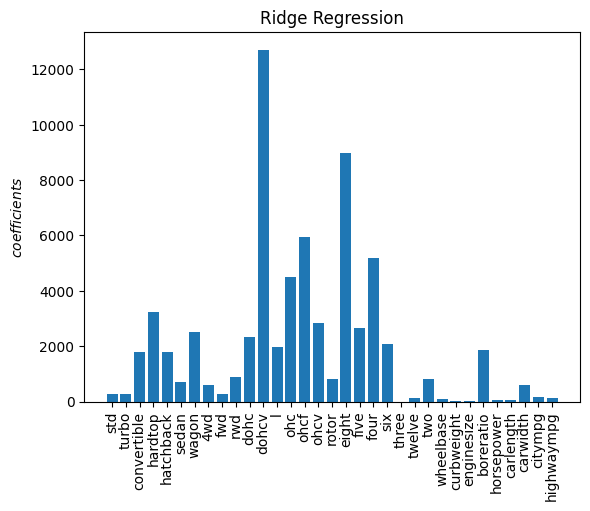

R^2 on training data for Ridge Regression model: 0.9262583145923291
R^2 on testing  data for Ridge Regression model: 0.8454081419624829





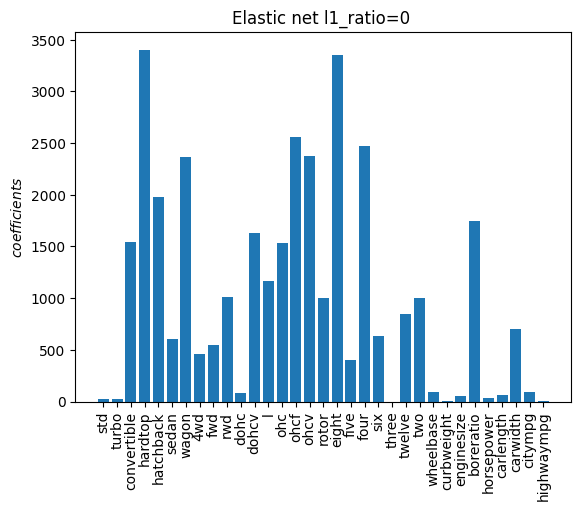

R^2 on training data for Elastic net l1_ratio=0  model: 0.9169259598993408
R^2 on testing  data for Elastic net l1_ratio=0  model: 0.8069174475383014


In [55]:
enet = ElasticNet(alpha=0.01, l1_ratio=0)
enet.fit(X_train,y_train)

rr = Ridge(alpha=0.01)
rr.fit(X_train,y_train)

plot_coef(X,rr,name="Ridge Regression")
print("\n\n")
plot_coef(X,enet,name="Elastic net l1_ratio=0 ")


Based on the above graphs and R2 performance metrics, let's analyze and compare the Ridge Regression and Elastic Net with l1_ratio=0 models.

1. **Performance and Mathematical Equivalence (R2 Scores)**

* Let's start by looking at the evaluation metrics printed directly below the graphs:

    |Model|Training R2|Testing R2|
    |---|---|---|
    |Ridge Regression|0.9263|0.8454|
    |Elastic Net (l1_ratio=0)|0.9169|0.8069|

    * At first glance, these models seem to have different scores. However, from a purely mathematical standpoint, Ridge and Elastic Net with l1_ratio=0 are identical models. Both use an L2 penalty (α∑w2) to shrink coefficients toward zero without eliminating them. The slight divergence in the R2 scores here comes down to how the two classes optimize the problem under the hood:

    * Ridge() in scikit-learn uses exact analytical solvers (such as Cholesky decomposition or Singular Value Decomposition) to find the absolute minimum of the loss function directly.

    * ElasticNet(l1_ratio=0) uses an iterative optimization technique (Coordinate Descent). Because it stops iterating once it reaches the tolerance threshold (tol), it often finds a very close approximation rather than the exact mathematical minimum.

2. **Feature Selection & Sparsity**

* Since both models are applying pure L2 regularization, their feature handling characteristics are the same:

    * No Variable Elimination: Neither model zeroes out any features. If you look at both bar charts, features like std, turbo, wagon, engine size, and highwaympg all retain non-zero bars.

    * Retaining Correlated Predictors: If you have multiple features that are highly correlated with one another, both models will keep all of them in the equation and distribute the weights across them.

3. **Coefficient Scale**

* While the overall "shape" of the coefficient distributions looks highly similar—meaning the same features are prioritized in both models—there is a noticeable difference in the y-axis scale.

    * **Ridge Regression**: The coefficients scale up to a maximum of 12,000 (with dohcv spiking the highest).

    * **Elastic Net** (l1_ratio=0): The coefficients are compressed much further, peaking at around 3,400 on the y-axis.

* This difference in absolute magnitude exists because the effective regularization strength isn't perfectly identical between the two classes when using the same default α parameters. The higher compression in the Elastic Net model is what ultimately led to a slightly lower test R2 (0.8069), indicating that it penalized the coefficients a bit too aggressively compared to the standalone Ridge model.

<BR>

**Summary Conclusion**

* **The Takeaway**: This comparison is a perfect real-world demonstration of why we should prefer Ridge() over ElasticNet(l1_ratio=0) when we want pure L2 regularization.

* **The Reason**: While they are mathematically identical, the dedicated solver in scikit-learn's Ridge() class is more computationally stable and precise, yielding a better test performance (0.8454 vs 0.8069) for our dataset without needing iterative hyperparameter tuning for tolerance or maximum iterations.

<BR>

## Exercise 4

Create a Pipeline object, apply polynomial features (degree = 2), perform data standardization, then apply Elastic Net with `alpha=0.1` and  `l1_ratio=0.1` parameters. Fit the model using the training data, then calculate the $R^2$ on the training and testing data.


In [56]:
Input=[ ('polynomial',PolynomialFeatures(include_bias=False,degree=2)), ('ss',StandardScaler()), ('model',ElasticNet(alpha=0.1, l1_ratio=0.1)) ]
pipe = Pipeline(Input)
pipe.fit(X_train, y_train)

print("R^2 on training data for Elastic Net (alpha=0.1, l1_ratio=0.1): ",pipe.score(X_train, y_train))
print("R^2 on testing  data for Elastic Net (alpha=0.1, l1_ratio=0.1): ",pipe.score(X_test, y_test))

R^2 on training data for Elastic Net (alpha=0.1, l1_ratio=0.1):  0.9747505819790091
R^2 on testing  data for Elastic Net (alpha=0.1, l1_ratio=0.1):  0.9108826638584331


## Exercise 5


Search for the best combination of  hyperparameters by creating  a  `GridSearchCV` object for Elastic Net Regression. Find the best parameter values using the pipeline object, as used in the above examples. Use`param_grid`, then find thee $R^2$ on the test data using the best estimator.


In [57]:
# 1. Given parameter grid and pipeline
param_grid = {
    "polynomial__degree": [1, 2, 3, 4, 5],
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "model__l1_ratio": [0.1, 0.25, 0.5, 0.75, 0.9]
}

Input = [
    ('polynomial', PolynomialFeatures(include_bias=False)), 
    ('ss', StandardScaler()), 
    ('model', ElasticNet(tol=0.2))
]
pipe = Pipeline(Input)

# 2. Set up the GridSearch
search = GridSearchCV(pipe, param_grid, n_jobs=2)

# 3. CORRECTED: Fit ONLY on the Training Data
search.fit(X_train, y_train)

# 4. Extract the best model found during training
best = search.best_estimator_

# 5. Evaluate the model's true performance on the unseen Test Data
test_score = best.score(X_test, y_test)

print(f"Optimal Parameters:  {search.best_params_}")
print(f"True Test R^2 Score: {test_score}")

Optimal Parameters:  {'model__alpha': 10, 'model__l1_ratio': 0.25, 'polynomial__degree': 3}
True Test R^2 Score: 0.9045702561251823


## Principal Component Analysis

Principal Component Analysis (PCA) is one of the most important and widely used techniques in data science. At its core, PCA is a dimensionality reduction technique. It takes a dataset with a large number of features (high dimensionality) and compresses it into a smaller set of new features, while retaining as much of the original information as possible.

<BR>

**Why Do We Need PCA?**

When you have a dataset with dozens or hundreds of features, you run into several challenges:

* **The Curse of Dimensionality**: As the number of features grows, the amount of data you need to generalize accurately grows exponentially.

* **Multicollinearity**: Many features are highly correlated (e.g., in a housing dataset, square_footage, number_of_rooms, and number_of_windows all move together). They are redundant.

* **Visualization**: Humans can easily visualize data in 2D or 3D, but it is impossible to visualize 10D or 50D data. PCA lets us compress dozens of features down to 2 or 3 so we can plot them on a graph.

<BR>

**How Do You Choose the Number of Components?**

To decide how many components to keep, data scientists use a **Scree Plot** or look at the **Cumulative Explained Variance**.

For example, after running PCA on a 10-feature dataset, scikit-learn will tell you the percentage of variance explained by each component:

*    **PC1**: Explains 70% of the variance.

*    **PC2**: Explains 20% of the variance.

*    **PC3**: Explains 5% of the variance.

If you keep just **PC1 and PC2**, you have successfully compressed your data **from 10 dimensions down to 2**, while **keeping 90%** of the original information (70%+20%).

<BR>

It is common to wonder why we need **PCA** if we already have **Ridge, Lasso, and ElasticNet**. All of them deal with high-dimensional data, but they approach the problem from two completely different mathematical angles: **Feature Selection/Shrinkage** vs. **Feature Transformation**.

* **Lasso & ElasticNet** reduce the number of features by throwing away the ones they think are useless.

* **PCA** reduces the number of features by merging them together into brand-new concepts.


To use the audio codec analogy, when we do PCA, we have two choices: keeping all components or dropping some.

1. PCA with All Components = Lossless Compression (FLAC)

* If we have a dataset with 10 features and we tell PCA to keep all 10 principal components, it is 100% lossless.

    * We can mathematically reconstruct the exact original data perfectly from those 10 components.

    * The catch: We haven't actually reduced your dimensions; we’ve just rotated the data.

2. PCA with Fewer Components = High-Quality Lossy Compression (MP3)

* In the real world, we use PCA to discard the components that have very little variance. When we drop the last few components:

    * What we keep: The massive, clear waves of information (the heavy bass and the vocals).

    * What we throw away: The tiny, high-frequency components that barely change (the background hiss or white noise).

    * Result: We lose a tiny bit of the original data, but we get rid of the "noise." Just like a good MP3 sounds identical to a CD to most listeners, a machine learning model often makes just as good—or even better—predictions using the compressed PCA features because the random noise was filtered out.

<BR>

"PCA is like taking a massive, uncompressed audio file and converting it into a compressed format. It strips out the irrelevant background noise (low-variance components) and keeps only the core melody (high-variance components) so the file is much smaller and easier to work with, without any noticeable drop in the music's quality."



<BR>

___

<BR>

In this example, we will explore Principal Component Analysis to reduce the dimensionality of our data.
We will do so by creating a Pipeline object first, then applying standard scaling and performing PCA, and then applying Elastic Net Regularization with the following parametrs: `tol=0.2`, `alpha=0.1` and  `l1_ratio=0.1`.
Finally, we will fit the model using the training data, then calculate the  $𝑅^2$  on the training and testing data sets.


Before adding PCA as a prep-processing step, we have to standardize our data. Scaling the features makes them have the same standard deviation.


In [58]:
scaler = StandardScaler()
X_train_scaled_array = scaler.fit_transform(X_train) # this returns a multi-D np array

# convert array to df
X_train_scaled = pd.DataFrame(
    X_train_scaled_array, 
    columns=X_train.columns, 
    index=X_train.index
)
X_train_scaled.columns = [f'{c} (scaled)' for c in X_train.columns]  # rename the columns

X_train_scaled

,diesel (scaled),gas (scaled),std (scaled),turbo (scaled),convertible (scaled),hardtop (scaled),hatchback (scaled),sedan (scaled),wagon (scaled),4wd (scaled),...,two (scaled),wheelbase (scaled),curbweight (scaled),enginesize (scaled),boreratio (scaled),horsepower (scaled),carlength (scaled),carwidth (scaled),citympg (scaled),highwaympg (scaled)
177,-0.302660,0.302660,0.482451,-0.482451,-0.190347,-0.169638,1.429179,-0.979236,-0.367315,-0.190347,...,-0.119098,0.573309,-0.221382,-0.121429,-0.038909,-0.340756,0.076413,0.235105,0.370118,0.270248
75,-0.302660,0.302660,-2.072751,2.072751,-0.190347,-0.169638,1.429179,-0.979236,-0.367315,-0.190347,...,-0.119098,0.622875,0.646950,0.314497,1.692945,1.723785,0.302880,0.924984,-0.986981,-1.017934
174,3.304038,-3.304038,-2.072751,2.072751,-0.190347,-0.169638,-0.699702,1.021204,-0.367315,-0.190347,...,-0.119098,0.573309,-0.179118,-0.412047,-0.186301,-0.813362,0.076413,0.235105,0.879030,0.431271
31,-0.302660,0.302660,0.482451,-0.482451,-0.190347,-0.169638,1.429179,-0.979236,-0.367315,-0.190347,...,-0.119098,-2.037199,-1.448956,-0.847973,-1.512828,-0.738740,-2.430901,-0.960684,1.048668,1.236385
12,-0.302660,0.302660,0.482451,-0.482451,-0.190347,-0.169638,-0.699702,1.021204,-0.367315,-0.190347,...,-0.119098,0.375042,0.262732,0.895732,-0.038909,0.380589,0.173470,-0.546757,-0.647706,-0.373843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,-0.302660,0.302660,0.482451,-0.482451,-0.190347,-0.169638,1.429179,-0.979236,-0.367315,-0.190347,...,-0.119098,0.044598,1.086878,1.307440,0.403266,1.350675,0.310968,0.878992,-0.986981,-0.856911
14,-0.302660,0.302660,0.482451,-0.482451,-0.190347,-0.169638,-0.699702,1.021204,-0.367315,-0.190347,...,-0.119098,0.755053,0.925507,0.895732,-0.038909,0.380589,1.160219,0.419073,-0.817344,-0.856911
92,-0.302660,0.302660,0.482451,-0.482451,-0.190347,-0.169638,-0.699702,1.021204,-0.367315,-0.190347,...,-0.119098,-0.731945,-1.220347,-0.726882,-0.628477,-0.912858,-0.756662,-1.006675,1.048668,1.075362
179,-0.302660,0.302660,0.482451,-0.482451,-0.190347,-0.169638,1.429179,-0.979236,-0.367315,-0.190347,...,-0.119098,0.655920,0.850585,1.065259,-0.186301,1.375549,0.715373,0.787008,-0.986981,-1.017934


Now, let's perform PCA.


In [59]:
pca = PCA()
pca.fit(X_train_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S


We can find the projection of the dataset onto the principal components, let's call it X_train_hat , this is our "new" dataset, it is the same shape as the original dataset.


In [60]:
X_train_scaled_hat = pca.transform(X_train_scaled)
print(X_train_scaled_hat.shape)

(143, 35)


Let's look at the new dataset as a dataframe.


In [61]:
X_train_scaled_hat_PCA = pd.DataFrame(columns=[f'Projection on Component {i+1}' for i in range(len(X_train_scaled.columns))], data=X_train_scaled_hat)
X_train_scaled_hat_PCA.head()

,Projection on Component 1,Projection on Component 2,Projection on Component 3,Projection on Component 4,Projection on Component 5,Projection on Component 6,Projection on Component 7,Projection on Component 8,Projection on Component 9,Projection on Component 10,...,Projection on Component 26,Projection on Component 27,Projection on Component 28,Projection on Component 29,Projection on Component 30,Projection on Component 31,Projection on Component 32,Projection on Component 33,Projection on Component 34,Projection on Component 35
0,-1.275886,-0.387124,-0.188967,-0.264790,0.478277,1.029336,-0.524741,0.088927,0.615081,0.352062,...,0.017035,0.059484,2.316264e-16,1.256357e-17,3.171660e-16,-4.371199e-16,-1.079776e-16,-1.253910e-16,8.266628e-17,-1.033681e-16
1,2.500963,0.720383,1.465152,0.090420,2.089170,1.631427,-0.821222,-2.142983,-1.101182,1.000920,...,0.038730,0.035999,8.662885e-16,3.751976e-16,4.316806e-16,-3.380436e-16,2.375749e-16,1.477097e-16,5.450918e-17,5.455210e-16
2,-0.865985,5.018715,0.135809,-1.107474,1.541035,-1.167279,1.686782,-0.180176,-0.079122,-0.543977,...,0.004004,-0.014941,2.502586e-17,1.738158e-16,7.544044e-16,-2.115976e-16,-9.460368e-17,1.295619e-16,3.791802e-17,-9.432231e-16
3,-4.363854,-1.442349,0.211128,-0.305657,1.246931,-0.077329,0.228809,-0.300396,0.832960,-0.080305,...,-0.000446,-0.107617,1.922971e-16,-1.031826e-16,-2.302877e-16,4.601300e-16,3.126293e-16,-1.475851e-16,-7.057845e-17,4.011687e-16
4,1.837786,-0.998711,-1.073234,-0.687229,-1.477782,-1.474179,0.463054,-0.821021,-0.318107,-0.070852,...,-0.143789,-0.129719,-3.494657e-16,-8.102367e-16,-1.099740e-15,5.482723e-16,3.399182e-16,-4.317473e-16,1.297995e-16,3.292484e-17


Now, let's see how much variance can be explained using these principal components (PCs). This is also known as a **Scree Plot**.


Text(0, 0.5, 'Variance')

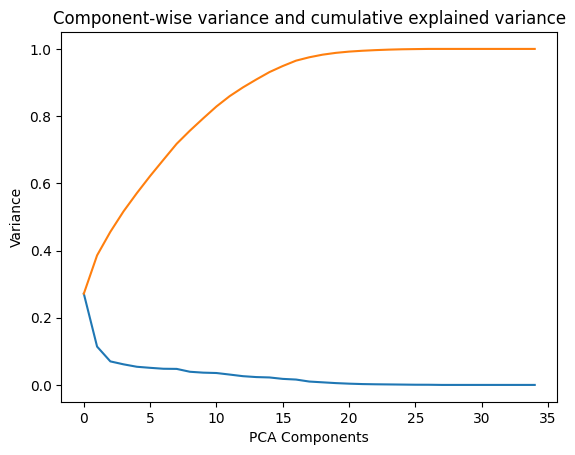

In [62]:
plt.plot(pca.explained_variance_ratio_)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title("Component-wise variance and cumulative explained variance")
plt.xlabel("PCA Components")
plt.ylabel("Variance")

In the graph above, the component-wise variance is depicted by the blue line, and the cumulative explained variance is explained by the orange line. We are able to explain \~100% of the variance using just the first 20 PCs. Let's filter our dataset down to these 20 PCs.


In [63]:
N = 20
X_train_hat_PCA = X_train_scaled_hat_PCA.iloc[:, :N]

Let's create an Elastic Net model where `tol=0.2`,  `alpha=0.1` and  `l1_ratio=0.1` and fit the data with this model.


In [64]:
enet = ElasticNet(tol = 0.2, alpha=100, l1_ratio=0.75)
enet.fit(X_train_hat_PCA, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",100
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.75
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.2
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


## Exercise 6

Overall in the pipeline the PCA let us specify the "lossiness", and then use the specify model (e.g. ElasticNet, Ridge, etc) to further regularized and give us a model we can use for doing prediction. We also need to include a Scaler as needed for PCA.

In this Exercise, create a Pipeline object, apply standard scaling, perform PCA and then finally fit an Elastic Net with `tol=0.2`, `alpha=0.1` and  `l1_ratio=0.1` parameters. Calculate the scores, $R^2$, on the training and testing data sets.


In [65]:
Input=[ 
    ('scaler',StandardScaler()), 
    ('pca',PCA(n_components = N)), 
    ('model',ElasticNet(tol =0.2, alpha=0.1, l1_ratio=0.1)) 
]
pipe = Pipeline(Input)

pipe.fit(X_train, y_train)

print("R^2 on training data ", pipe.score(X_train, y_train))
print("R^2 on testing  data ", pipe.score(X_test, y_test))

R^2 on training data  0.9108669657028968
R^2 on testing  data  0.749703049956508


# Congratulations! - You have completed the lab


## Author


<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML0101ENSkillsNetwork20718538-2021-01-01" target="_blank">Joseph Santarcangelo</a>


### Other Contributors

[Svitlana Kramar](https://www.linkedin.com/in/svitlana-kramar?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01)

[Kopal Garg](https://www.linkedin.com/in/gargkopal/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML240ENSkillsNetwork34171862-2022-01-01)


<!--## Change Log
-->


<!--| Date (YYYY-MM-DD) | Version | Changed By  | Change Description                               |
| ----------------- | ------- | ----------- | ------------------------------------------------ |
| 2022-05-02        | 0.1     | Svitlana K. | Reviewed and fixed minor code and grammar errors |
| 2022-05-10        | 0.2     | Kopal G.    | Added the PCA example                            |-->
